In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error


# **Model: ARMA**

In [2]:
def load_series(path):
    s = pd.read_csv(path, index_col=0, parse_dates=True)
    return s.iloc[:, 0]

y_train = load_series("../data/y_train.csv")
y_test = load_series("../data/y_test.csv")

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (2635,)
y_test shape: (293,)


# **Baseline**

In [3]:
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)

print("Mean P2 Reading:", round(y_train_mean, 2))
print("Baseline MAE:", round(baseline_mae, 2))

Mean P2 Reading: 9.26
Baseline MAE: 3.82


# **Hyper parameter Tuning**

ARMA needs both a p (AR order) and q (MA order), so this is a small grid search instead of
a single loop. Keeping the grid small since each ARIMA fit is a lot slower than AutoReg.

In [4]:
p_params = range(1, 4)
q_params = range(0, 3)

results = []
for p in p_params:
    for q in q_params:
        try:
            m = ARIMA(y_train, order=(p, 0, q)).fit()
            y_pred = m.predict()
            mae = mean_absolute_error(y_train, y_pred)
            results.append({"p": p, "q": q, "aic": m.aic, "train_mae": mae})
        except Exception as e:
            print(f"p={p}, q={q} failed: {e}")

result_df = pd.DataFrame(results)
result_df.sort_values("train_mae").head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dat

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dat

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dat

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,p,q,aic,train_mae
0,1,0,15040.699490,2.434386
4,2,1,15024.934614,2.434483
8,3,2,15027.507238,2.437514
3,2,0,15039.600155,2.437664
7,3,1,15040.276244,2.438078


In [5]:
best_row = result_df.loc[result_df["train_mae"].idxmin()]
best_p, best_q = int(best_row["p"]), int(best_row["q"])
print("Best (p, q):", (best_p, best_q))

Best (p, q): (1, 0)


# **Build Model**

In [6]:
model = ARIMA(y_train, order=(best_p, 0, best_q)).fit()
model.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                     P2   No. Observations:                 2635
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -7517.350
Date:                Wed, 02 Sep 2026   AIC                          15040.699
Time:                        09:19:04   BIC                          15058.329
Sample:                    09-01-2018   HQIC                         15047.083
                         - 12-19-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.2695      0.315     29.412      0.000       8.652       9.887
ar.L1          0.6439      0.003    195.315      0.000       0.637       0.650
sigma2        17.5965      0.066    267.135      0.000      17.467      17.726
===================================================================================
Ljung-Box (L1) (Q):                   1.32   Jarque-Bera (JB):           3993841.04
Prob(Q):                              0.25   Prob(JB):                         0.00
Heteroskedasticity (H):               0.64   Skew:                             6.35
Prob(H) (two-sided):                  0.00   Kurtosis:                       193.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# **Evaluate**

In [7]:
y_pred_train = model.predict()
train_mae = mean_absolute_error(y_train, y_pred_train)
print("Train MAE:", round(train_mae, 2))

Train MAE: 2.43


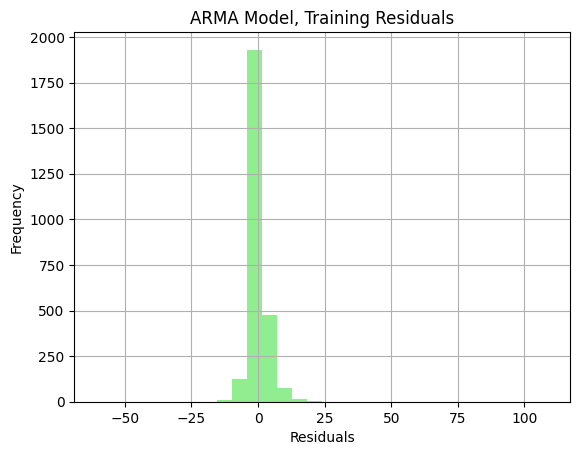

In [8]:
y_train_resid = pd.Series(model.resid, name="residuals")

y_train_resid.hist(bins=30, color="lightgreen")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("ARMA Model, Training Residuals")
plt.savefig("../images/arma_residuals_hist.png", dpi=150)
plt.show()


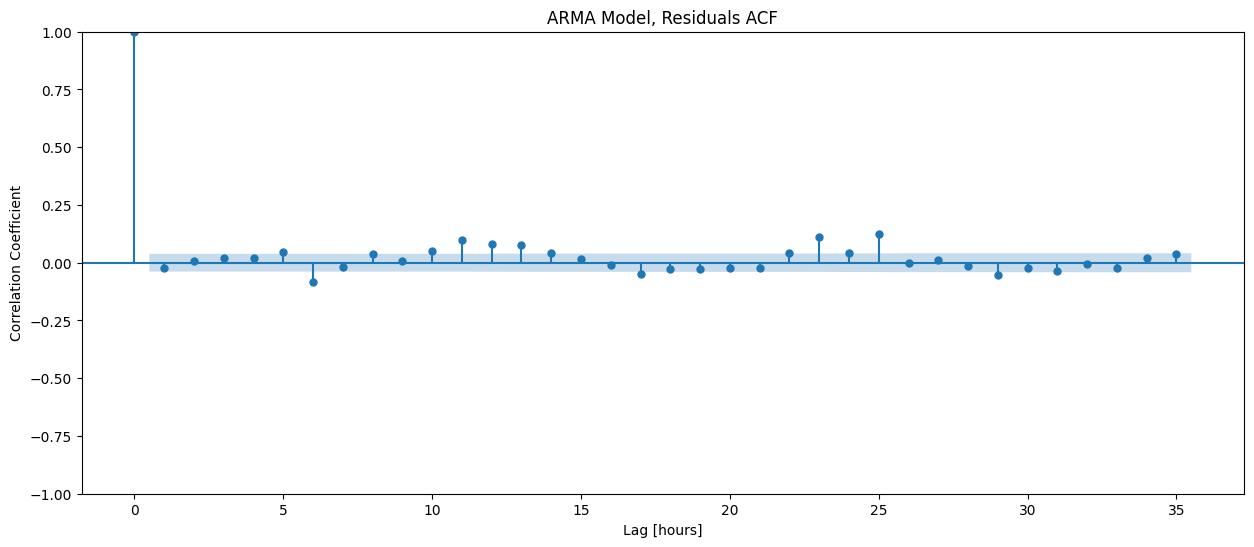

In [9]:
fig, ax = plt.subplots(figsize=(15,6))
plot_acf(y_train_resid, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("ARMA Model, Residuals ACF")
plt.savefig("../images/arma_residuals_acf.png", dpi=150)
plt.show()


# **Forecast on Test Set**

Refitting ARMA at every single hour like I did for AutoReg would take way too long here
(ARIMA fits are much slower). Doing a one-shot multi-step forecast for the whole test
window instead -- less realistic than walk-forward, but a reasonable trade-off given the
model's speed, and still a fair comparison since all 3 models get evaluated on the same
test set either way.

In [10]:
forecast = model.get_forecast(steps=len(y_test))
y_pred_test = forecast.predicted_mean
y_pred_test.index = y_test.index

test_mae = mean_absolute_error(y_test, y_pred_test)
print("Test MAE:", round(test_mae, 2))

Test MAE: 2.55


# **Communicate Results**

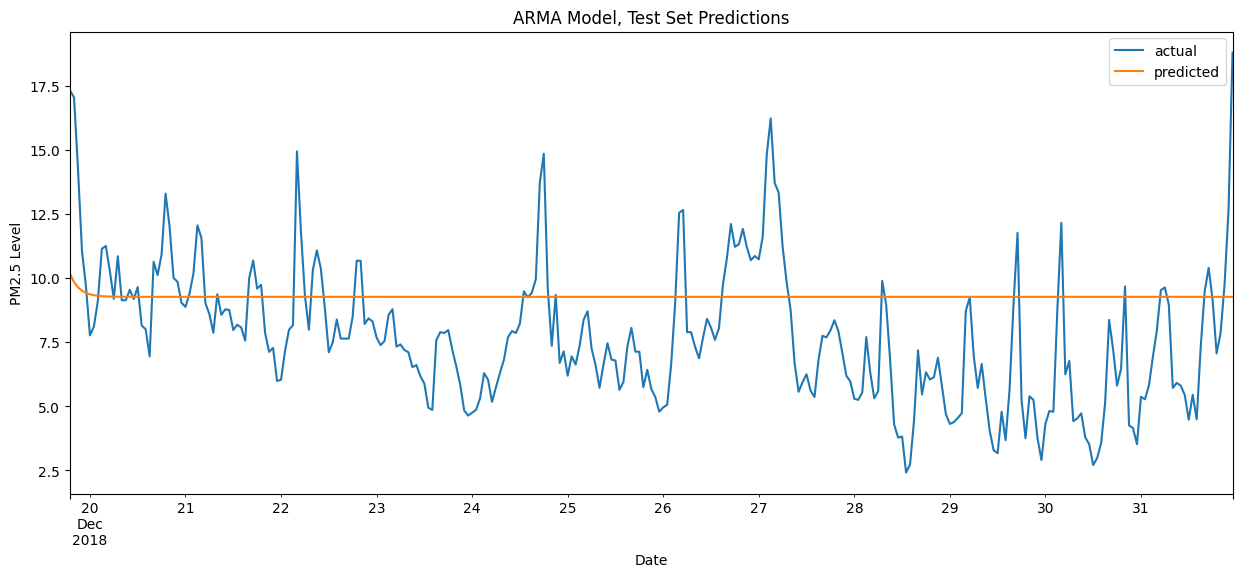

In [11]:
fig, ax = plt.subplots(figsize=(15,6))
y_test.plot(ax=ax, label="actual")
y_pred_test.plot(ax=ax, label="predicted")
plt.xlabel("Date")
plt.ylabel("PM2.5 Level")
plt.title("ARMA Model, Test Set Predictions")
plt.legend()
plt.savefig("../images/arma_test_predictions.png", dpi=150)
plt.show()


In [12]:
with open("../data/3_model_arma_results.txt", "w") as f:
    f.write(str(test_mae))
print("saved:", test_mae)

saved: 2.5455765939718744
